# Unit 12 code companion: Putting It Together

One dataset, one question, worked end to end the way the whole course says it should be done. Use this as the template for the capstone: notice how much of it happens before any model is fitted.

Run the cells in order. Each section matches a moment in the slides. The point is to see the mechanism move when you change the inputs, so change them.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

rng = np.random.default_rng(220)
plt.rcParams["figure.figsize"] = (7, 3.5)

## The question

*A bike-share operator asks: how many bikes should we deploy tomorrow, and what will it cost us to be wrong?* That is a prediction question with a decision attached, which means the deliverable is not a model. It is a number, an interval, and a recommendation.

## Step 1. Interrogate the data before modeling it

Where did it come from, what is one observation, and who is missing?

In [2]:
bikes = pd.read_csv("https://richardson.byu.edu/220/bikes.csv")
print(bikes.shape)
print(bikes.dtypes.to_dict())
print(f"\nmissing values per column: {bikes.isna().sum().sum()} total")
print(f"rows: {len(bikes)} consecutive days")
print(f"lag-1 autocorrelation of Count: {bikes['Count'].autocorr(1):.3f}   "
      f"<-- days are NOT independent")
print(f"\nRainfall is nonzero on {(bikes.Rainfall > 0).mean():.1%} of days")
print(f"Seasons present: {sorted(bikes.Seasons.unique())}")

(365, 8)
{'Count': dtype('int64'), 'Temperature': dtype('float64'), 'Humidity': dtype('int64'), 'Wind_speed': dtype('float64'), 'Visibility': dtype('int64'), 'Rainfall': dtype('float64'), 'Seasons': dtype('O'), 'Holiday': dtype('O')}

missing values per column: 0 total
rows: 365 consecutive days
lag-1 autocorrelation of Count: 0.501   <-- days are NOT independent

Rainfall is nonzero on 6.0% of days
Seasons present: ['Autumn', 'Spring', 'Summer', 'Winter']


Two things already matter. Days are autocorrelated, so a random train/test split leaks information across the boundary. The data also covers only one year, so anything we say about next year assumes the world does not move.

## Step 2. Look at the outcome before choosing a method



mean 699, median 709, SD 431, skew 0.07, min 0, max 1798


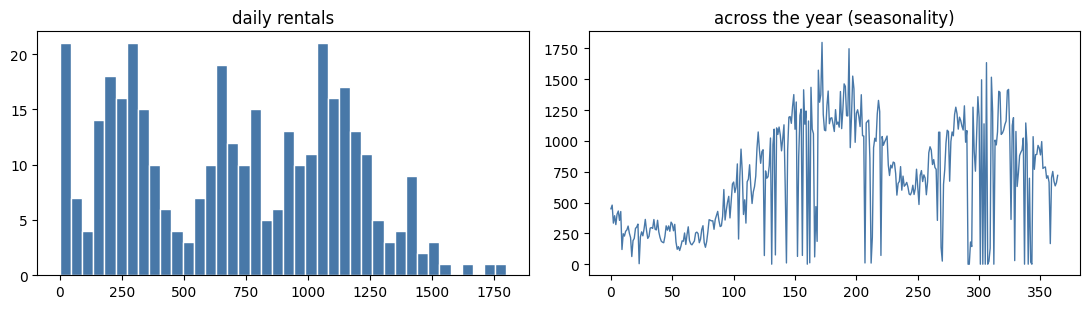

In [3]:
c = bikes["Count"]
print(f"mean {c.mean():.0f}, median {c.median():.0f}, SD {c.std():.0f}, "
      f"skew {stats.skew(c):.2f}, min {c.min()}, max {c.max()}")
fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
axes[0].hist(c, bins=40, color="#4878a8", edgecolor="white"); axes[0].set_title("daily rentals")
axes[1].plot(c.values, color="#4878a8", lw=1); axes[1].set_title("across the year (seasonality)")
plt.tight_layout(); plt.show()

## Step 3. Split honestly, given what one observation is

Because days are correlated, we hold out a contiguous block rather than random days.

In [4]:
split = int(len(bikes)*0.7)
train, test = bikes.iloc[:split], bikes.iloc[split:]
feats = ["Temperature", "Humidity", "Wind_speed", "Visibility", "Rainfall"]

model = RandomForestRegressor(n_estimators=400, random_state=0).fit(train[feats], train["Count"])
pred_test = model.predict(test[feats])
resid = test["Count"].values - pred_test

print(f"training RMSE : {np.sqrt(np.mean((train['Count'] - model.predict(train[feats]))**2)):.0f}")
print(f"held-out RMSE : {np.sqrt(np.mean(resid**2)):.0f}")
print(f"\nfor comparison, always predicting the training mean: "
      f"{np.sqrt(np.mean((test['Count'] - train['Count'].mean())**2)):.0f}")

training RMSE : 71
held-out RMSE : 403

for comparison, always predicting the training mean: 448


Always print the trivial baseline. A model is only worth deploying if it beats *predict the average*, and it is surprising how often that check is skipped.

## Step 4. An interval from the model's own mistakes



In [5]:
lo, hi = np.percentile(resid, [5, 95])
tomorrow = pd.DataFrame([{"Temperature": 20, "Humidity": 50, "Wind_speed": 2,
                          "Visibility": 1500, "Rainfall": 0}])
point = model.predict(tomorrow[feats])[0]
print(f"point prediction     : {point:,.0f} rentals")
print(f"90% interval         : {point+lo:,.0f} to {point+hi:,.0f}")
print(f"interval width       : {hi-lo:,.0f} rentals")

half = len(resid)//2
lo_c, hi_c = np.percentile(resid[:half], [5, 95])
covered = ((test['Count'].values[half:] >= pred_test[half:] + lo_c) &
           (test['Count'].values[half:] <= pred_test[half:] + hi_c)).mean()
print(f"\ncalibration check: nominal 90%, actual coverage {covered:.0%}")

point prediction     : 951 rentals
90% interval         : -96 to 1,321
interval width       : 1,417 rentals

calibration check: nominal 90%, actual coverage 40%


## Step 5. Turn the distribution into a decision

Each bike costs $3 for the day and each rental earns $9. The point forecast is not the answer to 'how many bikes'.

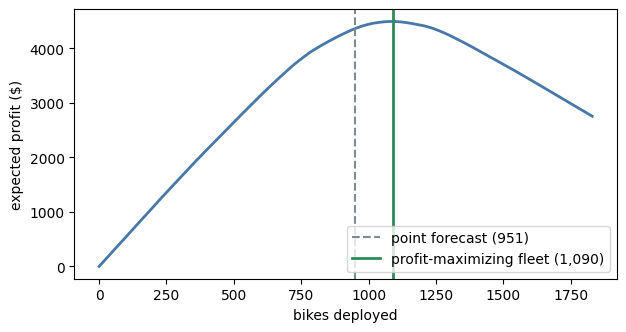

deploying the point forecast : $4,366/day
deploying the optimum        : $4,494/day


In [6]:
# Tomorrow's demand is the point forecast plus an error drawn from the errors
# the model actually made on days it had never seen.
demand_scenarios = np.clip(point + resid[rng.integers(0, len(resid), 20_000)], 0, None)

fleets = np.arange(0, int(demand_scenarios.max()), 10)
profits = [(9*np.minimum(demand_scenarios, f) - 3*f).mean() for f in fleets]
best = fleets[int(np.argmax(profits))]

plt.plot(fleets, profits, color="#4878a8", lw=2)
plt.axvline(point, ls="--", color="#7f8c8d", label=f"point forecast ({point:,.0f})")
plt.axvline(best, color="#2e8b57", lw=2, label=f"profit-maximizing fleet ({best:,})")
plt.xlabel("bikes deployed"); plt.ylabel("expected profit ($)"); plt.legend(); plt.show()

print(f"deploying the point forecast : ${(9*np.minimum(demand_scenarios, point) - 3*point).mean():,.0f}/day")
print(f"deploying the optimum        : ${max(profits):,.0f}/day")

## Step 6. The deliverable

The recommendation below is what actually gets handed over. Notice what makes it defensible: a comparison against the trivial baseline, an interval built from real out-of-sample errors, a coverage check on that interval, a fleet size chosen from costs rather than from the point forecast, and an explicit statement of when it stops being valid.

In [7]:
print(f"""RECOMMENDATION
  deploy               : {best:,} bikes
  expected demand      : {point:,.0f} rentals
  90% range            : {point+lo:,.0f} to {point+hi:,.0f}
  expected profit      : ${max(profits):,.0f}/day
  vs point-forecast fleet: ${max(profits) - (9*np.minimum(demand_scenarios, point) - 3*point).mean():,.0f}/day better

  caveats: one year, one city, so next season is assumed to resemble last;
           weather beyond the observed range is extrapolation.
""")

RECOMMENDATION
  deploy               : 1,090 bikes
  expected demand      : 951 rentals
  90% range            : -96 to 1,321
  expected profit      : $4,494/day
  vs point-forecast fleet: $128/day better

  caveats: one year, one city, so next season is assumed to resemble last;
           weather beyond the observed range is extrapolation.

